## Imports

In [19]:
import os
import json
import warnings

import numpy as np
import pandas as pd

from phase1_utils import (
    notebook_setup,
    ENCODING_MAPS,
    build_model_table
)
from phase3_utils import time_split

warnings.filterwarnings("ignore")


## Environment Setup

In [20]:
# Create output folder

OUTPUT_DIR = "Outputs_Phase6"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output folder created: {OUTPUT_DIR}")

Output folder created: Outputs_Phase6


## Load data

In [21]:
ctx = notebook_setup(
    phase_output_dir=OUTPUT_DIR,
    verbose=True
)

df = ctx["df"]

print("\nDataset Shape:", df.shape)

df.head()

🔧 phase1_utils — notebook setup
────────────────────────────────────────
📦 Loading CSVs into SQLite...
  patients :  5,000 rows × 7 cols
  visits   : 25,000 rows × 8 cols
  billing  : 25,000 rows × 7 cols
  ✅ SQLite DB ready — 7 indexes + 2 views created.
🔗 Building merged DataFrame...
  Merged shape : 25,000 rows × 20 columns
  Date range   : 2025-01-20 → 2026-01-20
📁 Creating output folder...
  ✅ Output folder ready → S:\Emeritus_Course slides\Capstone_Project\Outputs_Phase6/
────────────────────────────────────────
✅ Setup complete. Everything is ready.


Dataset Shape: (25000, 20)


,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,city,insurance_provider,chronic_flag,registration_date,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,Bangalore,CareOne,1,2025-08-14,1,"23,577.37",0.00,Rejected,16.00,2025-06-18
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,Hyderabad,SecureLife,1,2025-10-29,2,"38,178.81","38,178.81",Paid,18.00,2025-10-09
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,Chennai,HealthPlus,1,2025-07-04,3,"5,038.97","5,038.97",Paid,NaN,2025-01-20
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,Delhi,MediCareX,0,2026-01-20,4,"22,813.34","22,813.34",Paid,16.00,2025-12-24
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,Bangalore,HealthPlus,1,2025-03-29,5,"27,106.95","27,106.95",Paid,14.00,2025-09-23


## Define Validation rules

In [22]:
NUMERIC_RANGES = {
    "age": (0, 120),
    "visit_month": (1, 12),
    "visit_dayofweek": (0, 6),
    "chronic_flag": (0, 1),
    "approval_ratio": (0, 1),
    "length_of_stay_hours": (0, 500),
    "payment_days": (0, 365)
}

## Define validation Function

In [23]:
def validate_dataframe(df):
    """
    Phase 6 data validation checks.
    """

    report = {
        "missing_values": {},
        "range_violations": {},
        "unseen_categories": {}
    }

    # --------------------------------------------------
    # Missing values
    # --------------------------------------------------

    for col in df.columns:

        report["missing_values"][col] = int(
            df[col].isnull().sum()
        )

    # --------------------------------------------------
    # Numeric range checks
    # --------------------------------------------------

    for col, (low, high) in NUMERIC_RANGES.items():

        if col not in df.columns:
            continue

        violations = (
            ((df[col] < low) | (df[col] > high))
            .sum()
        )

        report["range_violations"][col] = int(violations)

    # --------------------------------------------------
    # Unseen categories
    # --------------------------------------------------

    for col, mapping in ENCODING_MAPS.items():

        if col not in df.columns:
            continue

        allowed = set(mapping.keys())

        current = set(df[col].dropna().unique())

        unseen = current - allowed

        report["unseen_categories"][col] = list(unseen)

    return report

## Run Validation

In [24]:
validation_report = validate_dataframe(df)

validation_report

{'missing_values': {'visit_id': 0,
  'patient_id': 0,
  'visit_date': 0,
  'department': 0,
  'visit_type': 0,
  'length_of_stay_hours': 0,
  'risk_score': 0,
  'doctor_id': 0,
  'age': 0,
  'gender': 0,
  'city': 0,
  'insurance_provider': 0,
  'chronic_flag': 0,
  'registration_date': 0,
  'bill_id': 0,
  'billed_amount': 0,
  'approved_amount': 1318,
  'claim_status': 0,
  'payment_days': 790,
  'billing_date': 0},
 'range_violations': {'age': 0,
  'chronic_flag': 0,
  'length_of_stay_hours': 0,
  'payment_days': 0},
 'unseen_categories': {'department': [],
  'visit_type': [],
  'gender': [],
  'city': [],
  'insurance_provider': [],
  'risk_score': [],
  'claim_status': []}}

## Create Summary Tables

In [25]:
missing_df = pd.DataFrame(
    validation_report["missing_values"].items(),
    columns=["Column", "Missing_Count"]
)

range_df = pd.DataFrame(
    validation_report["range_violations"].items(),
    columns=["Column", "Violation_Count"]
)

unseen_df = pd.DataFrame(
    validation_report["unseen_categories"].items(),
    columns=["Column", "Unseen_Values"]
)

print("Missing Values")
display(missing_df.sort_values(
    "Missing_Count",
    ascending=False
))

print("\nRange Violations")
display(range_df)

print("\nUnseen Categories")
display(unseen_df)

Missing Values


,Column,Missing_Count
16,approved_amount,1318
18,payment_days,790
0,visit_id,0
1,patient_id,0
3,department,0
2,visit_date,0
4,visit_type,0
5,length_of_stay_hours,0
8,age,0
9,gender,0



Range Violations


,Column,Violation_Count
0,age,0
1,chronic_flag,0
2,length_of_stay_hours,0
3,payment_days,0



Unseen Categories


,Column,Unseen_Values
0,department,[]
1,visit_type,[]
2,gender,[]
3,city,[]
4,insurance_provider,[]
5,risk_score,[]
6,claim_status,[]


## Overall Quality status

In [26]:
total_missing = missing_df["Missing_Count"].sum()

total_violations = range_df["Violation_Count"].sum()

if total_missing == 0 and total_violations == 0:
    status = "PASS"

elif total_violations == 0:
    status = "WARNING"

else:
    status = "FAIL"

print("="*50)
print("DATA QUALITY STATUS")
print("="*50)

print(f"Total Missing Values   : {total_missing}")
print(f"Total Range Violations : {total_violations}")
print(f"Overall Status         : {status}")

DATA QUALITY STATUS
Total Missing Values   : 2108
Total Range Violations : 0
Overall Status         : WARNING


## Save Report

In [27]:
with open(
    f"{OUTPUT_DIR}/data_validation_report.json",
    "w"
) as f:

    json.dump(
        validation_report,
        f,
        indent=4
    )

print(
    f"Saved: {OUTPUT_DIR}/data_validation_report.json"
)

Saved: Outputs_Phase6/data_validation_report.json


## Business Interpretation

In [28]:
print("""
Business Interpretation

1. Missing values indicate potential data capture issues.
2. Range violations indicate erroneous operational entries.
3. Unseen categories may cause prediction failures in production.
4. Continuous monitoring ensures reliable AI deployment.
""")


Business Interpretation

1. Missing values indicate potential data capture issues.
2. Range violations indicate erroneous operational entries.
3. Unseen categories may cause prediction failures in production.
4. Continuous monitoring ensures reliable AI deployment.



# Create a Baseline Dataset

In [29]:
model_df = build_model_table(df)
print(model_df.shape)
model_df.head()

(25000, 30)


,visit_id,patient_id,visit_date,age,chronic_flag,los_capped,visit_frequency,avg_los_per_patient,days_since_registration,billed_amount_capped,approval_ratio,provider_rejection_rate,payment_days_capped,visit_month,visit_dayofweek,visit_quarter,department,visit_type,gender,city,insurance_provider,department_encoded,visit_type_encoded,gender_encoded,city_encoded,insurance_provider_encoded,risk_score,risk_score_encoded,claim_status,claim_status_encoded
0,1,756,2025-10-18,90,1,3.48,2,3.73,65,"23,577.37",0.00,0.15,16.00,10,5,4,Cardiology,ER,M,Bangalore,CareOne,0,0,1,0,0,Low,1,Rejected,2
1,2,4102,2025-04-06,30,1,15.31,4,32.02,0,"38,178.81",1.00,0.16,18.00,4,6,2,Orthopedics,OPD,M,Hyderabad,SecureLife,5,2,1,3,3,High,0,Paid,0
2,3,2964,2025-07-13,25,1,34.36,4,20.54,9,"5,038.97",1.00,0.15,0.00,7,6,3,ICU,ER,F,Chennai,HealthPlus,3,0,0,1,1,Low,1,Paid,0
3,4,4496,2025-11-19,75,0,37.89,7,28.17,0,"22,813.34",1.00,0.15,16.00,11,2,4,Cardiology,ER,M,Delhi,MediCareX,0,0,1,2,2,High,0,Paid,0
4,5,1930,2025-03-29,80,1,16.78,5,22.99,0,"27,106.95",1.00,0.15,14.00,3,5,1,General,ICU,M,Bangalore,HealthPlus,2,1,1,0,1,Medium,2,Paid,0


## Time based Split

In [30]:
train_df, test_df = time_split(model_df)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

  Split date : 2025-11-08
  Train      : 19,947 rows  (79.8%)  up to 2025-11-07
  Test       : 5,053 rows  (20.2%)  from 2025-11-08
Train: (19947, 30)
Test : (5053, 30)


## PSI Function

In [31]:
def calculate_psi(expected, actual, buckets=10):

    expected = np.array(expected)
    actual = np.array(actual)

    breakpoints = np.percentile(
        expected,
        np.arange(0, buckets + 1) / buckets * 100
    )

    expected_percents = []
    actual_percents = []

    for i in range(len(breakpoints)-1):

        expected_count = (
            (expected >= breakpoints[i]) &
            (expected < breakpoints[i+1])
        ).sum()

        actual_count = (
            (actual >= breakpoints[i]) &
            (actual < breakpoints[i+1])
        ).sum()

        expected_pct = max(expected_count / len(expected), 0.0001)
        actual_pct = max(actual_count / len(actual), 0.0001)

        expected_percents.append(expected_pct)
        actual_percents.append(actual_pct)

    psi = np.sum(
        (np.array(expected_percents) -
         np.array(actual_percents))
        *
        np.log(
            np.array(expected_percents) /
            np.array(actual_percents)
        )
    )

    return round(psi, 4)

## Feature Drift Analysis

In [32]:
numeric_features = [

    'age',
    'los_capped',
    'visit_frequency',
    'avg_los_per_patient',
    'days_since_registration',
    'billed_amount_capped',
    'approval_ratio',
    'payment_days_capped'

]

drift_results = []

for feature in numeric_features:

    psi = calculate_psi(
        train_df[feature],
        test_df[feature]
    )

    if psi < 0.10:
        status = "Stable"

    elif psi < 0.25:
        status = "Moderate Drift"

    else:
        status = "Significant Drift"

    drift_results.append({
        "Feature": feature,
        "PSI": psi,
        "Status": status
    })

drift_df = pd.DataFrame(drift_results)

drift_df

,Feature,PSI,Status
0,age,0.00,Stable
1,los_capped,0.00,Stable
2,visit_frequency,0.00,Stable
3,avg_los_per_patient,0.00,Stable
4,days_since_registration,1.26,Significant Drift
5,billed_amount_capped,0.00,Stable
6,approval_ratio,0.00,Stable
7,payment_days_capped,0.00,Stable


## Visualize Drift

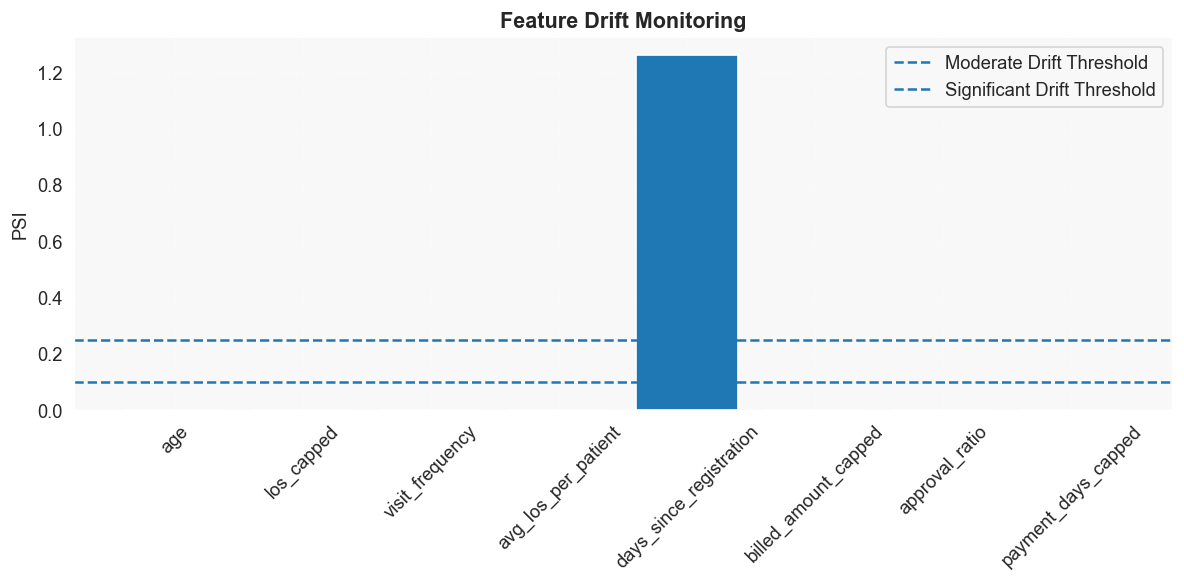

<Figure size 768x576 with 0 Axes>

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(
    drift_df["Feature"],
    drift_df["PSI"]
)
plt.axhline(
    0.10,
    linestyle="--",
    label="Moderate Drift Threshold"
)
plt.axhline(
    0.25,
    linestyle="--",
    label="Significant Drift Threshold"
)
plt.xticks(rotation=45)
plt.ylabel("PSI")
plt.title("Feature Drift Monitoring")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(
    f"{OUTPUT_DIR}/feature_drift_monitoring.png",
    bbox_inches="tight",
    dpi=300
)

## Save Drift Report

In [34]:
drift_df.to_csv(
    f"{OUTPUT_DIR}/feature_drift_report.csv",
    index=False
)

print(
    f"Saved: {OUTPUT_DIR}/feature_drift_report.csv"
)

Saved: Outputs_Phase6/feature_drift_report.csv


## Saving Drift Interpretation

In [36]:
drift_interpretation = """
FEATURE DRIFT INTERPRETATION

PSI < 0.10
→ Feature distribution is stable.

0.10 ≤ PSI < 0.25
→ Moderate drift detected.

PSI ≥ 0.25
→ Significant drift detected.

Recommendation:
Features showing significant drift should trigger model review
and possible retraining.
"""

with open(
    f"{OUTPUT_DIR}/business_interpretation_drift.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(drift_interpretation)

print("Drift interpretation saved.")

Drift interpretation saved.


## Businesss Interpretation

In [35]:
print("""
PSI Interpretation

PSI < 0.10  → Stable

0.10 ≤ PSI < 0.25
→ Moderate Drift

PSI ≥ 0.25
→ Significant Drift

Significant drift indicates retraining should be considered.
""")


PSI Interpretation

PSI < 0.10  → Stable

0.10 ≤ PSI < 0.25
→ Moderate Drift

PSI ≥ 0.25
→ Significant Drift

Significant drift indicates retraining should be considered.



## Saving Business Interpretations

In [38]:
business_interpretation = """
PHASE 6 — DATA QUALITY MONITORING

Business Interpretation:

1. Missing values indicate potential data capture issues.
2. Range violations indicate erroneous operational entries.
3. Unseen categories may cause prediction failures in production.
4. Continuous monitoring ensures reliable AI deployment.
5. Data validation protects the hospital system from invalid requests.
"""

with open(
    f"{OUTPUT_DIR}/business_interpretation_data_validation.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(business_interpretation)

print("Business interpretation saved.")

Business interpretation saved.


## Governance Document

In [39]:
governance_text = """
HOSPITAL RISK INTELLIGENCE PLATFORM
PHASE 6 — GOVERNANCE AND COMPLIANCE DOCUMENT

1. SYSTEM PURPOSE
The system predicts:
- Patient Visit Risk (Low/Medium/High)
- Insurance Claim Outcome (Paid/Pending/Rejected)

Predictions are intended to support hospital operations and finance teams.

------------------------------------------------------------

2. MODEL ASSUMPTIONS

- Models are trained on historical hospital data.
- Data distributions remain relatively stable over time.
- Categorical values must match predefined vocabularies.
- Predictions are advisory and do not replace expert judgement.

------------------------------------------------------------

3. MODEL LIMITATIONS

- Performance may degrade if patient demographics change.
- New insurance providers or departments may introduce unseen categories.
- Extreme operational events (pandemics, disasters) are not represented.
- Historical biases present in training data may affect predictions.

------------------------------------------------------------

4. HUMAN OVERSIGHT

Clinical and finance teams must review predictions before taking action.

The AI system should never make fully autonomous decisions.

------------------------------------------------------------

5. MONITORING REQUIREMENTS

- Daily data quality checks.
- Weekly drift monitoring.
- Monthly performance review.
- Audit logging for all predictions.

------------------------------------------------------------

6. RETRAINING POLICY

Models should be retrained when:

- Significant feature drift is detected (PSI > 0.25).
- Model performance degrades substantially.
- New operational policies are introduced.
- Every six months as preventive maintenance.

------------------------------------------------------------

7. AUDITABILITY

Every prediction is logged with:
- Timestamp
- Model version
- Endpoint used
- Input hash
- Predicted class
- Probability scores

------------------------------------------------------------

8. COMPLIANCE

Patient identifiers should be protected.
Prediction logs must be securely stored.
Access to models and logs should be restricted.

------------------------------------------------------------

Document Version : 1.0
Model Version    : 1.0.0
"""

with open(
    f"{OUTPUT_DIR}/governance_document.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(governance_text)

print("governance_document.txt saved.")

governance_document.txt saved.


## Prediction and monitoring report

In [40]:
import pandas as pd
from pathlib import Path

LOG_FILE = Path("logs/predictions.jsonl")

if LOG_FILE.exists():

    logs = []

    with open(LOG_FILE, "r") as f:
        for line in f:
            logs.append(eval(line))

    logs_df = pd.DataFrame(logs)

    monitoring_report = pd.DataFrame({
        "Metric": [
            "Total Predictions",
            "Unique Endpoints",
            "Model Version"
        ],

        "Value": [
            len(logs_df),
            logs_df["endpoint"].nunique(),
            logs_df["model_version"].iloc[-1]
        ]
    })

else:

    monitoring_report = pd.DataFrame({
        "Metric": [
            "Total Predictions",
            "Unique Endpoints",
            "Model Version"
        ],

        "Value": [
            0,
            0,
            "1.0.0"
        ]
    })

monitoring_report.to_csv(
    f"{OUTPUT_DIR}/prediction_monitoring_report.csv",
    index=False
)

display(monitoring_report)

print("prediction_monitoring_report.csv saved.")

,Metric,Value
0,Total Predictions,0
1,Unique Endpoints,0
2,Model Version,1.0.0


prediction_monitoring_report.csv saved.


## Drift Detection prediction

In [46]:
# ==========================================================
# PREDICTION DRIFT DETECTION
# ==========================================================

from phase6_utils import detect_prediction_drift

# Encode risk classes

risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

baseline_preds = (
    test_df["risk_score"]
    .map(risk_mapping)
    .astype(int)
)

# Simulate production predictions

new_preds = baseline_preds.sample(
    frac=1,
    replace=True,
    random_state=42
).reset_index(drop=True)

prediction_drift = detect_prediction_drift(
    baseline_preds=baseline_preds,
    new_preds=new_preds,
    class_names=["Low", "Medium", "High"],
    model_name="Visit Risk Model"
)


  Visit Risk Model — Prediction Drift
  Class          Baseline        New    Shift    Alert
  ──────────────────────────────────────────────────
  Low              49.61%     49.42%   -0.20%        ✅
  Medium           29.92%     29.51%   -0.42%        ✅
  High             20.46%     21.08%   +0.61%        ✅
  Prediction PSI: 0.0  ✅ Stable


# Convert drift dictionary to dataframe

In [47]:
# Convert drift dictionary to dataframe

pred_drift_rows = []

for cls in ["Low", "Medium", "High"]:

    d = prediction_drift[cls]

    pred_drift_rows.append({
        "Class": cls,
        "Baseline (%)": d["baseline_pct"],
        "New (%)": d["new_pct"],
        "Shift (%)": d["shift_pct"],
        "Alert": d["alert"]
    })

prediction_drift_df = pd.DataFrame(pred_drift_rows)

display(prediction_drift_df)

,Class,Baseline (%),New (%),Shift (%),Alert
0,Low,49.61,49.42,-0.20,False
1,Medium,29.92,29.51,-0.42,False
2,High,20.46,21.08,0.61,False


In [48]:
# Save report

prediction_drift_df.to_csv(
    f"{OUTPUT_DIR}/prediction_drift_report.csv",
    index=False
)

print(
    f"Saved: {OUTPUT_DIR}/prediction_drift_report.csv"
)

Saved: Outputs_Phase6/prediction_drift_report.csv


## Prediction drift visualization

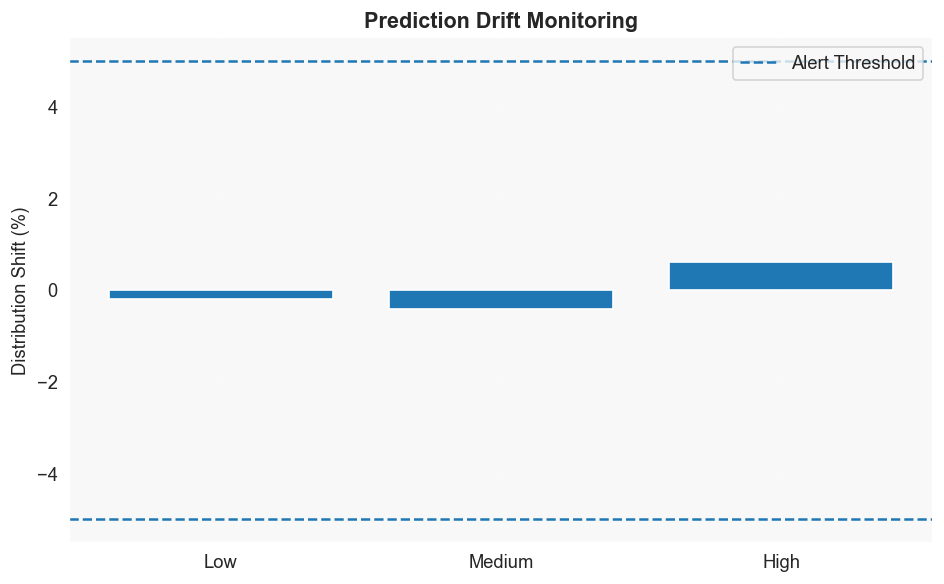

Saved: Outputs_Phase6/prediction_drift.png


In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    prediction_drift_df["Class"],
    prediction_drift_df["Shift (%)"]
)

plt.axhline(
    5,
    linestyle="--",
    label="Alert Threshold"
)

plt.axhline(
    -5,
    linestyle="--"
)

plt.ylabel("Distribution Shift (%)")
plt.title("Prediction Drift Monitoring")

plt.legend()
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/prediction_drift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {OUTPUT_DIR}/prediction_drift.png"
)

## Audit Log

In [44]:
from phase6_utils import AuditLogger

audit = AuditLogger(
    f"{OUTPUT_DIR}/audit_log.csv"
)

audit.log_event(
    "validation",
    "Data validation completed"
)

audit.log_event(
    "feature_drift",
    "Feature drift analysis completed"
)

audit.log_event(
    "prediction_drift",
    "Prediction drift analysis completed"
)

audit.log_event(
    "governance",
    "Governance review completed"
)

print("Audit events logged.")

audit_df = audit.load()
display(audit_df.head())

Audit events logged.


,timestamp,event_type,model,visit_id,prediction,confidence,detail,logged_by
0,2026-06-27T16:48:49.891038,validation,NaN,NaN,NaN,NaN,Data validation completed,phase6_utils
1,2026-06-27T16:48:49.891283,feature_drift,NaN,NaN,NaN,NaN,Feature drift analysis completed,phase6_utils
2,2026-06-27T16:48:49.891431,prediction_drift,NaN,NaN,NaN,NaN,Prediction drift analysis completed,phase6_utils
3,2026-06-27T16:48:49.891562,governance,NaN,NaN,NaN,NaN,Governance review completed,phase6_utils


## Audit Summary

In [45]:
audit_summary = pd.DataFrame({
    "Metric": [
        "Total Events",
        "Unique Event Types",
        "Date Range"
    ],

    "Value": [
        len(audit_df),
        audit_df["event_type"].nunique(),
        f"{audit_df['timestamp'].min()} → {audit_df['timestamp'].max()}"
    ]
})

display(audit_summary)
audit_summary.to_csv(
    f"{OUTPUT_DIR}/audit_log_summary.csv",
    index=False
)

print(
    f"Saved: {OUTPUT_DIR}/audit_log_summary.csv"
)

,Metric,Value
0,Total Events,4
1,Unique Event Types,4
2,Date Range,2026-06-27T16:48:49.891038 → 2026-06-27T16:48:49.891562


Saved: Outputs_Phase6/audit_log_summary.csv


## Phase 6 Summary Report

In [41]:
summary_text = f"""
HOSPITAL RISK INTELLIGENCE PLATFORM
PHASE 6 SUMMARY REPORT

========================================================
PHASE 6 OBJECTIVE
========================================================

Ensure long-term reliability, safety, and compliance
of deployed machine learning models.

========================================================
IMPLEMENTED COMPONENTS
========================================================

1. Data Validation
   ✓ Missing value checks
   ✓ Range validation
   ✓ Unseen category detection

2. Drift Monitoring
   ✓ Feature drift detection using PSI
   ✓ Drift report generation

3. Monitoring
   ✓ Prediction audit logging
   ✓ Prediction monitoring report

4. Governance
   ✓ Model assumptions documented
   ✓ Limitations documented
   ✓ Retraining strategy defined

========================================================
GENERATED ARTIFACTS
========================================================

- data_validation_report.json
- feature_drift_report.csv
- feature_drift_monitoring.png
- governance_document.txt
- prediction_monitoring_report.csv

========================================================
RECOMMENDATIONS
========================================================

1. Execute data quality checks daily.
2. Monitor drift weekly.
3. Review model performance monthly.
4. Retrain models every six months or when
   significant drift is detected.

========================================================
PHASE 6 STATUS : COMPLETED
========================================================
"""

with open(
    f"{OUTPUT_DIR}/phase6_summary_report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

print("phase6_summary_report.txt saved.")

phase6_summary_report.txt saved.
